# Algoritmo de Detección de Fuego NOAA/GOES (Fase 1)

Este cuaderno implementa de manera interactiva la **Fase 1** del algoritmo de detección sub-píxel de fuego con datos del sensor ABI (Advanced Baseline Imager) a bordo de los satélites GOES-R, basándose en el documento oficial *Algorithm Theoretical Basis Document (ATBD)*.

En esta fase exploraremos desde la carga y conversión de las temperaturas de brillo hasta la generación de las máscaras de salida que identifican píxeles con potencial fuego.

## 1. Importación de Librerías y Constantes Globales

El ATBD define valores de saturación, valores faltantes y coeficientes específicos del instrumento ABI para las funciones de Planck.

* **FPT (Focal Plane Temperature) Threshold:** Si la temperatura del plano focal excede los 90 K, el algoritmo crea una banda híbrida de onda larga para mitigar problemas.
* **Buffer de Saturación:** Un píxel se considera erróneo si su temperatura excede en 5 K la temperatura de saturación definida por el sistema.

In [3]:
import numpy as np
def obtener_mascara_noaa_colab(timestamp_str: str, region_cfg: dict, satellite: str = "G16") -> np.ndarray:
    """
    Descarga el producto oficial ABI-L2-FDCF (Fire Mask) vía goes2go,
    aplica el recorte geográfico exacto y devuelve la matriz categórica de fuegos.
    """
    dt = pd.to_datetime(timestamp_str)
    print(f"🔍 Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para {timestamp_str}...")
    
    # En L2 no se especifica el parámetro 'bands'
    g = GOES(satellite=satellite, product="ABI-L2-FDCF", domain="F")
    
    files_df = g.nearesttime(dt, return_as="filelist")
    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos L2 FDC para la fecha {timestamp_str}")
        
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    # Abrimos de forma diferida y recortamos usando tus slices originales
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        # La variable estándar del producto FDC de la NOAA es 'Mask'
        mask_noaa = ds.sel(x=xs, y=ys)["Mask"].values.astype(np.int16)
        
    print(f" ✅ Máscara oficial NOAA descargada con éxito. Matriz shape: {mask_noaa.shape}")
    return mask_noaa

In [4]:
from __future__ import annotations

import logging
import os
from typing import Optional

import numpy as np

# Configuración básica de logs para el entorno Colab
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

# ══════════════════════════════════════════════════════════════════════════════
# Constantes globales
# ══════════════════════════════════════════════════════════════════════════════

BR_TEMP_MISS_VAL: float = -999.0   # Valor centinela de temperatura de brillo faltante
SAT_TEMP: float         = 335.0    # Temperatura de saturación del sensor (K)
SAT_BUFF: float         = 5.0      # Buffer de saturación (K)
FPT_THRESHOLD: float    = 90.0     # Umbral de temperatura del plano focal

# Constantes de Planck para cada banda ABI usada
# Basadas en los coeficientes espectrales del ABI (GOES-R PUG L1b Rev 2)
# c1 = 2*h*c^2  [mW / (m^2·sr·cm^-4)]
# c2 = h*c/k    [K·cm]
_ABI_BAND_PARAMS: dict[int, dict[str, float]] = {
    7:  {"fk1": 202526.8, "fk2": 3698.03, "bc1": 0.4759,  "bc2": 0.99810},
    13: {"fk1": 671922.5, "fk2": 1285.62, "bc1": 0.3764,  "bc2": 0.99891},
    14: {"fk1": 620818.5, "fk2": 1216.99, "bc1": 0.3572,  "bc2": 0.99912},
    15: {"fk1": 520364.0, "fk2": 1107.43, "bc1": 0.3011,  "bc2": 0.99933},
}

## 2. Funciones Auxiliares de Radiometría (Transformaciones de Planck)

A lo largo del algoritmo, particularmente en los cálculos de reflectividad y en la corrección atmosférica (Secciones 3.4.2.2 y 3.4.2.8), es necesario convertir la **Temperatura de Brillo ($T_b$)** a **Radianza ($L$)** y viceversa[cite: 22, 209].

El algoritmo de la NOAA utiliza la función de Planck y su inversa para transformar valores entre bandas, lo cual permite comparar la respuesta radiativa de la banda de 3.9 µm (Banda 7) con las bandas de onda larga (Bandas 13 y 14) en un mismo "espacio de radianza".

## Variables Fundamentales del Algoritmo

Antes de comenzar con la detección de incendios, es útil definir las variables físicas que aparecen repetidamente en el ATBD y en la implementación.

### Bandas ABI utilizadas

| Banda | Longitud de onda | Variable |
|---------|---------|---------|
| 2 | 0.64 µm | `refl2` |
| 7 | 3.9 µm | `bTemp7`, `rad7` |
| 13 | 10.3 µm | `bTemp13`, `rad13` |
| 14 | 11.2 µm | `bTemp14`, `rad14` |
| 15 | 12.3 µm | `bTemp15`, `rad15` |

### Variables geométricas

| Variable | Significado |
|-----------|-------------|
| `ang_cenital_sol` | Solar Zenith Angle (SZA) |
| `ang_resp_sol` | Solar Glint Angle |
| `ang_cenital_local` | Local Zenith Angle |

### Productos derivados

| Variable | Significado |
|-----------|-------------|
| `refl` | Reflectivity Product |
| `albedo` | Reflectancia corregida por cos(SZA) |
| `vis_brightness` | Brillo visible escalado |
| `mascara_fuego` | Fire Mask NOAA |
| `fail_char` | Razón de fallo de caracterización |

### Convención

Todas las temperaturas están expresadas en Kelvin y todas las radianzas utilizan las unidades nativas del sensor ABI.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Funciones auxiliares de radiometría (Planck)
# ══════════════════════════════════════════════════════════════════════════════

def _rad_from_temp(band: int, temp: np.ndarray | float) -> np.ndarray | float:
    """
    Temperatura de brillo → radianza equivalente para *band*.
    Usa la función de Planck inversa con los coeficientes del ABI.
    """
    p   = _ABI_BAND_PARAMS[band]
    t   = (temp - p["bc1"]) / p["bc2"]
    # Evitar división por cero / overflow en exp
    t   = np.where(t > 0, t, np.nan) if isinstance(t, np.ndarray) else max(t, 1e-6)
    rad = p["fk1"] / (np.exp(p["fk2"] / t) - 1.0)
    return rad

def _temp_from_rad(band: int, rad: np.ndarray | float) -> np.ndarray | float:
    """
    Radianza → temperatura de brillo equivalente para *band*.
    """
    p    = _ABI_BAND_PARAMS[band]
    safe = np.where(rad > 0, rad, np.nan) if isinstance(rad, np.ndarray) else max(rad, 1e-12)
    t    = p["fk2"] / np.log(p["fk1"] / safe + 1.0)
    return p["bc1"] + p["bc2"] * t

def temp_to_rad(src_band: int, dst_band: int, temp: np.ndarray | float) -> np.ndarray | float:
    """
    Dada una temperatura de brillo en src_band, calcula la radianza
    equivalente en dst_band mediante la función de Planck.
    """
    rad_src = _rad_from_temp(src_band, temp)
    if src_band == dst_band:
        return rad_src
    return _rad_from_temp(dst_band, temp)

def rad_to_temp(src_band: int, dst_band: int, rad: np.ndarray | float) -> np.ndarray | float:
    """
    Dada una radianza en src_band, devuelve la temperatura de brillo
    equivalente en dst_band.
    """
    temp_src = _temp_from_rad(src_band, rad)
    if src_band == dst_band:
        return temp_src
    return _temp_from_rad(dst_band, _rad_from_temp(src_band, temp_src))

In [ ]:
def _compute_pixel_area(
    range: np.ndarray, #En dónde computar el área
    latitudes: np.ndarray,
    longitudes: np.ndarray,
) -> np.ndarray:
    """
    Pixel area in km² using the 4×4 box great-circle method (ATBD 3.4.2.10).

    Corners at (i±2, j±2), distances divided by 4 before area calculation.
    Heron's formula for the parallelogram.
    """
    L, W = latitudes.shape
    index = np.argwhere(range)

    areas = np.zeros_like(latitudes)

    def _clamp(v, lo, hi):
        return max(lo, min(hi, v))
    
    def great_circle_km(r1, c1, r2, c2):
        lat1 = np.radians(latitudes [r1, c1])
        lat2 = np.radians(latitudes [r2, c2])
        lon1 = np.radians(longitudes[r1, c1])
        lon2 = np.radians(longitudes[r2, c2])
        arg  = (np.sin(lat1)*np.sin(lat2)
                + np.cos(lat1)*np.cos(lat2)*np.cos(abs(lon2-lon1)))
        arg  = np.clip(arg, -1.0, 1.0)
        return 6378.137 * np.arccos(arg)

    for (i,j) in index:
        c = [
            (_clamp(i-2, 0, L-1), _clamp(j-2, 0, W-1)),
            (_clamp(i+2, 0, L-1), _clamp(j-2, 0, W-1)),
            (_clamp(i+2, 0, L-1), _clamp(j+2, 0, W-1)),
            (_clamp(i-2, 0, L-1), _clamp(j+2, 0, W-1)),
        ]

    
        # Sides of the 4×4 box divided by 4
        a = great_circle_km(*c[0], *c[1]) / 4.0   # top-left → bottom-left
        b = great_circle_km(*c[1], *c[2]) / 4.0   # bottom-left → bottom-right
        d = great_circle_km(*c[0], *c[2]) / 4.0   # diagonal (used in Heron)

        # Heron for one triangle × 2 → parallelogram area
        s = (a + b + d) / 2.0
        try:
            area = 2.0 * np.sqrt(max(0.0, s * (s-a) * (s-b) * (s-d)))
        except Exception:
            area = 0.0
        areas[i,j] = area 

    return areas

## 3. Acceso a la Tabla de Búsqueda TPW (Total Precipitable Water)

Para corregir la atenuación producida por el vapor de agua en la atmósfera, el algoritmo utiliza el modelo NCEP para determinar el Agua Precipitable Total (TPW) y lo mapea contra el Ángulo Cenital Local (SZA). 

El documento ATBD especifica que esta información se extrae de una Tabla de Búsqueda (LUT) fija que no se interpola, la cual cuenta con **6 filas y 35 columnas**:
* **Filas:** Bin de TPW, Offset de radianza, y transmisividad/extinción para las bandas de 4 µm y 11 µm.
* **Columnas:** Combinaciones de 5 "bins" de TPW (intervalos de 10 mm) y 7 "bins" de SZA (intervalos de 10 grados).

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Funciones auxiliares: LUT TPW — acceso
# ══════════════════════════════════════════════════════════════════════════════

def _lut_lookup(lut: np.ndarray, line: int, column: int) -> float:
    """
    Acceso a la LUT de TPW.
    (El pseudo usa índices base-1 para columnas, así que restamos 1 para Python).
    """
    return float(lut[line, column - 1])   

def _lut_indices(tpw: float, ang_cenital_local_deg: float) -> tuple[int, int]:
    """
    Devuelve (bin_tpw, indice_col) para la LUT, asegurando que los índices 
    no superen los límites físicos definidos en el ATBD.
    """
    # bin_tpw ∈ [1, 5]  — cada 10 mm de TPW
    bin_tpw = int(round(tpw / 10.0))
    bin_tpw = max(1, min(5, bin_tpw))

    # bin_ang  ∈ [1, 7]  — cada 10° de ángulo cenital local
    bin_ang = int(round(ang_cenital_local_deg / 10.0))
    bin_ang = max(1, min(7, bin_ang))

    # Construcción de la columna para la tabla (7 ángulos por cada bin de TPW)
    indice_col = 7 * (bin_tpw - 1) + bin_ang
    return bin_tpw, indice_col

## 4. Fase 1: Preprocesamiento y Diferencias de Radianza (§3.4.2.2)

El núcleo físico de la detección sub-píxel de incendios se basa en que los fuegos emiten muchísima más energía en la banda de onda corta infrarroja (Banda 7 - 3.9 µm) que en las bandas de onda larga (Banda 13 y 14 - 10.3 µm y 11.2 µm). 

Para medir esta anomalía térmica de forma homogénea, el algoritmo realiza lo siguiente:
1. Convierte las temperaturas de brillo de las bandas 13 y 14 al "espacio de radianza" de la banda 7 usando las funciones de Planck.
2. Calcula los deltas de radianza: $\Delta L_{7-14} = L_7 - L_{14\to7}$ y $\Delta L_{7-13} = L_7 - L_{13\to7}$.
3. **Control de Calidad del Sensor (Híbrido):** Si la temperatura del plano focal del satélite ($FPT$) supera los $90\text{ K}$, el sensor puede presentar distorsiones. En ese caso, el algoritmo conmuta automáticamente a una banda híbrida tomando el mínimo absoluto de ambos deltas para mitigar falsos positivos.

También calcularemos el **Albedo** y el **Brillo Visible** si la banda 2 (visible) está disponible, lo cual nos servirá para el test de nubes diurno.

In [9]:
def preprocesar_imagenes_abi(
    bTemp7: np.ndarray, rad7: np.ndarray,
    bTemp13: np.ndarray, rad13: np.ndarray,
    bTemp14: np.ndarray, rad14: np.ndarray,
    refl2: Optional[np.ndarray],
    ang_cenital_sol: np.ndarray,
    FPT: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Implementa estrictamente la sección §3.4.2.2 del ATBD.
    Retorna: (refl, albedo, vis_brightness)
    """
    logger.info("Ejecutando §3.4.2.2 — Preprocesamiento de radianzas")
    
    # 1. Transformación de radianzas usando la función de Planck
    rad14_a_7 = temp_to_rad(14, 7, bTemp14)
    rad13_a_7 = temp_to_rad(13, 7, bTemp13)

    # 2. Cálculo de diferencias espectrales
    refl_7_14 = rad7 - rad14_a_7
    refl_7_13 = rad7 - rad13_a_7

    # 3. Lógica de conmutación por temperatura del plano focal (FPT)
    if FPT > FPT_THRESHOLD:
        logger.warning(f"FPT={FPT}K > {FPT_THRESHOLD}K. Activando mitigación por banda híbrida.")
        refl = np.minimum(np.abs(refl_7_14), np.abs(refl_7_13))
    else:
        refl = refl_7_14

    # 4. Cálculo de Albedo e Intensidad Visible (Banda 2 de día)
    L, W = bTemp7.shape
    albedo = np.full((L, W), np.nan, dtype=np.float32)
    vis_brightness = np.full((L, W), np.nan, dtype=np.float32)

    if refl2 is not None:
        cos_sza = np.cos(np.radians(ang_cenital_sol))
        # Evitar divisiones por cero en el limbo de la Tierra
        cos_sza_safe = np.where(np.abs(cos_sza) > 1e-6, cos_sza, np.nan)
        albedo = (refl2 / cos_sza_safe).astype(np.float32)
        vis_brightness = (255 * np.sqrt(np.maximum(refl2, 0))).astype(np.float32)

    return refl, albedo, vis_brightness

## 5. Inicialización de Máscaras y Tests Iniciales de Descarte (§3.4.2.3)

Antes de gastar cómputo analizando píxel por píxel con ventanas estadísticas móviles, el algoritmo ejecuta una serie de **filtros rápidos (umbrales rígidos)**. Si un píxel no cumple las condiciones geométricas o físicas mínimas para albergar un incendio, se le asigna un código de estado definitivo y se lo salta.

### Códigos de salida que aplicaremos en esta fase:
* **`40`**: Píxel en el espacio exterior (fuera del disco terrestre).
* **`50`**: Ángulo cenital solar $> 80^\circ$ (píxeles en el limbo/terminador).
* **`60`**: Ángulo solar $< 10^\circ$ o riesgo alto de resplandor solar (*sunglint*).
* **`120` / `121`**: Valores faltantes (*missing values*) en las bandas térmicas críticas.
* **`123` / `124`**: Saturación extrema del sensor (fuera de límites físicos tolerables).
* **`126` / `127`**: Píxeles absurdamente fríos ($< 200\text{ K}$), clasificados como no utilizables.
* **`125`**: Radianzas físicas negativas (errores de telemetría L1b).
* **`100`**: Píxel válido / Sin fuego detectado (valor por defecto inicial).

In [10]:
def aplicar_filtros_iniciales(
    bTemp7: np.ndarray, rad7: np.ndarray,
    bTemp14: np.ndarray, rad14: np.ndarray,
    ang_cenital_sol: np.ndarray,
    ang_resp_sol: np.ndarray
) -> np.ndarray:
    """
    Aplica de manera eficiente y vectorizada los tests iniciales de descarte (§3.4.2.3).
    Devuelve la matriz 'mascara_fuego' con los píxeles ya clasificados o marcados como 100.
    """
    L, W = bTemp7.shape
    # Inicializamos todos los píxeles como válidos (100) por defecto
    mascara_fuego = np.full((L, W), 100, dtype=np.int16)
    
    # 1. Identificación de píxeles de espacio exterior
    es_espacio = (bTemp7 == BR_TEMP_MISS_VAL) & (bTemp14 == BR_TEMP_MISS_VAL)
    mascara_fuego = np.where(es_espacio, 40, mascara_fuego)
    
    # 2. Ángulo cenital solar extremo (Limbo de la Tierra)
    mascara_fuego = np.where((mascara_fuego == 100) & (ang_cenital_sol > 80), 50, mascara_fuego)
    
    # 3. Geometría propensa a Sunglint o ángulos cenitales muy bajos
    cond_glint = (ang_cenital_sol < 10) | (ang_resp_sol < 10)
    mascara_fuego = np.where((mascara_fuego == 100) & cond_glint, 60, mascara_fuego)
    
    # 4. Valores faltantes (Missing Values) individuales
    mascara_fuego = np.where((mascara_fuego == 100) & (bTemp7 == BR_TEMP_MISS_VAL), 120, mascara_fuego)
    mascara_fuego = np.where((mascara_fuego == 100) & (bTemp14 == BR_TEMP_MISS_VAL), 121, mascara_fuego)
    
    # 5. Saturación más allá del buffer permitido (SAT_TEMP + SAT_BUFF = 340K)
    umbral_sat = SAT_TEMP + SAT_BUFF
    mascara_fuego = np.where((mascara_fuego == 100) & (bTemp7 > umbral_sat), 123, mascara_fuego)
    mascara_fuego = np.where((mascara_fuego == 100) & (bTemp14 > umbral_sat), 124, mascara_fuego)
    
    # 6. Radianzas negativas anómalas
    mascara_fuego = np.where((mascara_fuego == 100) & ((rad7 < 0) | (rad14 < 0)), 125, mascara_fuego)
    
    # 7. Temperaturas por debajo del límite físico utilizable (200K)
    mascara_fuego = np.where((mascara_fuego == 100) & (bTemp7 < 200), 126, mascara_fuego)
    mascara_fuego = np.where((mascara_fuego == 100) & (bTemp14 < 200), 127, mascara_fuego)
    
    return mascara_fuego

## 6. Test Mínimo de Actividad Térmica (§3.4.2.3)

Luego de descartar píxeles inválidos, el algoritmo realiza un primer test térmico para eliminar regiones frías que claramente no corresponden a incendios.

La detección de incendios se basa en que la Banda 7 (3.9 µm) es especialmente sensible a anomalías térmicas, mientras que la Banda 14 (11.2 µm) representa mejor la temperatura de fondo de la superficie.

Por este motivo se calcula:

$$
\Delta T = |T_{3.9} - T_{11.2}|
$$

Si ambas temperaturas son muy similares y además el píxel es frío, resulta extremadamente improbable que exista un foco de incendio.

La implementación NOAA asigna el código:

| Código | Descripción |
|----------|----------|
| 201 | Píxel demasiado frío para contener fuego |

Este filtro reduce significativamente la cantidad de píxeles que deben analizarse en las etapas posteriores.

In [11]:
def aplicar_test_actividad_termica(
    mascara_fuego: np.ndarray,
    bTemp7: np.ndarray,
    bTemp14: np.ndarray,
) -> np.ndarray:
    """
    §3.4.2.3 — Minimum fire activity threshold.

    Código NOAA:
        201 -> píxel demasiado frío
    """

    delta_t = np.abs(bTemp7 - bTemp14)

    condicion = (
        (mascara_fuego == 100)
        & (delta_t < 2)
        & ((bTemp7 <= 273) | (bTemp14 <= 273))
    )

    mascara_fuego = np.where(
        condicion,
        201,
        mascara_fuego
    )

    return mascara_fuego

## 7. Umbrales Dependientes de la Iluminación Solar (§3.4.2.3)

La respuesta espectral de la Banda 7 depende fuertemente de las condiciones de iluminación.

Durante el día, la señal observada en 3.9 µm contiene simultáneamente:

- emisión térmica de la superficie,
- radiación solar reflejada.

Durante la noche solamente permanece la componente térmica.

Por esta razón el algoritmo NOAA ajusta dinámicamente algunos umbrales utilizando el ángulo cenital solar (SZA).

A partir de este ángulo se calculan dos parámetros fundamentales:

### Temperatura mínima aceptable

$$
T_{3.9,\min}
$$

Representa la temperatura mínima requerida para considerar un píxel como posible candidato.

### Umbral de reflectancia

$$
T_{3.9,\text{refl}}
$$

Se utiliza posteriormente para diferenciar incrementos térmicos reales de aumentos de señal provocados por reflexión solar.

Estos umbrales cambian gradualmente entre condiciones diurnas y nocturnas.

In [12]:
def calcular_umbrales_dia_noche(
    ang_cenital_sol: np.ndarray
):
    """
    §3.4.2.3

    Calcula:

        bTemp7_min
        bTemp7_refl_threshold
    """

    cos_sza = np.cos(np.radians(ang_cenital_sol))

    es_dia = ang_cenital_sol < 90

    offset_7 = np.where(
        es_dia,
        15.0 * cos_sza,
        0.0
    )

    offset_7_refl = np.where(
        es_dia,
        5.0 * cos_sza,
        0.0
    )

    bTemp7_min = 285.0 + offset_7

    bTemp7_refl_threshold = 315.0 + offset_7_refl

    return (
        bTemp7_min,
        bTemp7_refl_threshold
    )

## 8. Detección Preliminar de Nubes (§3.4.2.3)

Las nubes representan una de las principales fuentes de falsas detecciones en algoritmos de anomalías térmicas.

Antes de buscar incendios, NOAA identifica píxeles cuya firma espectral es compatible con nubosidad.

Para ello combina información proveniente de:

- Banda 7 (3.9 µm)
- Banda 14 (11.2 µm)
- Banda 15 (12.3 µm)
- Albedo visible
- Geometría de observación

Los píxeles clasificados como nube reciben códigos específicos dentro de la máscara NOAA y son excluidos de las etapas posteriores de detección.

Esta estrategia reduce considerablemente la cantidad de falsos positivos producidos por topes nubosos fríos o superficies altamente reflectivas.ss

In [13]:
def aplicar_cloud_tests(
    mascara_fuego: np.ndarray,
    bTemp7: np.ndarray,
    bTemp14: np.ndarray,
    bTemp15: np.ndarray | None,
    albedo: np.ndarray,
    ang_cenital_sol: np.ndarray,
    ang_cenital_local: np.ndarray,
):
    """
    §3.4.2.3 Cloud tests

    Códigos NOAA:
        200
        205
        215
        220
        225
        230
    """

    mascara_nubes = np.zeros_like(
        mascara_fuego,
        dtype=bool
    )

    candidatos = mascara_fuego == 100

    # 200
    cond_200 = candidatos & (bTemp14 < 270)

    mascara_fuego = np.where(cond_200, 200, mascara_fuego)
    mascara_nubes |= cond_200

    # 205
    candidatos = mascara_fuego == 100

    cond_205 = candidatos & (
        (bTemp7 - bTemp14) < -4
    )

    mascara_fuego = np.where(cond_205, 205, mascara_fuego)
    mascara_nubes |= cond_205

    # 215
    candidatos = mascara_fuego == 100

    sza_ok = (
        (ang_cenital_sol <= 70)
        |
        (
            (ang_cenital_sol <= 60)
            &
            (ang_cenital_local <= 60)
        )
    )

    cond_215 = (
        candidatos
        & sza_ok
        & np.isfinite(albedo)
        & (albedo > 0.38)
    )

    mascara_fuego = np.where(cond_215, 215, mascara_fuego)
    mascara_nubes |= cond_215

    if bTemp15 is not None:

        # 220
        candidatos = mascara_fuego == 100

        cond_220 = (
            candidatos
            & (bTemp15 <= 265)
        )

        mascara_fuego = np.where(
            cond_220,
            220,
            mascara_fuego
        )

        mascara_nubes |= cond_220

        # 225
        candidatos = mascara_fuego == 100

        diff_14_15 = bTemp14 - bTemp15

        cond_225 = (
            candidatos
            & (bTemp14 < 270)
            & (diff_14_15 < -4)
        )

        mascara_fuego = np.where(
            cond_225,
            225,
            mascara_fuego
        )

        mascara_nubes |= cond_225

        # 230
        candidatos = mascara_fuego == 100

        cond_230 = (
            candidatos
            & (bTemp14 < 270)
            & (diff_14_15 > 60)
        )

        mascara_fuego = np.where(
            cond_230,
            230,
            mascara_fuego
        )

        mascara_nubes |= cond_230

    return mascara_fuego, mascara_nubes

## 8. Along Scan reflectivity test (§3.4.2.4)

In [ ]:
def along_scan_reflectivity_test(
        mascara_fuego,
        fail_char,
        albedo,
        refl,
        es_dia,
        bTemp7,
        bTemp7_min,
        bTemp14_eff
    ):
    # vecinos ±3
    refl_m3 = np.empty_like(refl)
    refl_p3 = np.empty_like(refl)

    refl_m3[:, :3] = refl[:, [0]]
    refl_m3[:, 3:] = refl[:, :-3]

    refl_p3[:, -3:] = refl[:, [-1]]
    refl_p3[:, :-3] = refl[:, 3:]

    neighbor_cond = (refl_m3 < 0.2) | (refl_p3 < 0.2)

    day_mask = (
        es_dia
        & ~np.isnan(albedo)
        & (albedo >= 0.38)
        & (bTemp7 < 320.0)
        & neighbor_cond
    )

    night_mask = (
        ~(es_dia & ~np.isnan(albedo))
        & (bTemp7 < bTemp7_min)
        & (bTemp7 >= 200)
        & neighbor_cond
    )

    mascara_fuego[day_mask] = 240
    mascara_fuego[night_mask] = 245

    sat_flag = (bTemp7 >= 411.76) | (bTemp14_eff >= 339.9) #Flag de saturacion
    

    fail_char[sat_flag] = 7

    return mascara_fuego,fail_char,sat_flag


## Calcular estadísticas de fondo (§3.4.2.5)

Se computa una serie de estadísticas sobre una ventana cuadrada alrededor de cada píxel. Dicha ventana se expande hasta tener al menos un 20% de píxeles válidos dentro de ella, entendiéndose "pixel válido" como un pixel de tierra ni muy frío, ni muy cálido y ni muy reflectivo. 

Se utiliza tanto un enfoque "estadístico", calculando las estadísticas directamente a partir de los valores del fondo, así como un enfoque utilizando histogramas, optando finalmente por la opción que resulte en menor desviación en los resultados.

Las estadísticas calculadas son las siguientes:


|Nombre|Descripción|
|------|------|
|temp7_bkg_mean|Temperatura de brillo media en el canal 7.|
|temp14_bkg_mean|Temperatura de brillo media en el canal 14.|
|vis_mean_bkg|Brillo visible medio (8 bits).|
|temp7_bkg_stddev|Desviación estándar de la temperatura de brillo de en el canal 7.|
|temp14_bkg_stddev|Desviación estándar de la temperatura de brillo de en el canal 14.|
|vis_bkg_histogram_stddev|Desviación estándar del brillo visible calculado (8 bits).|
|histogram_bin_largest_count|Brillo visible medio calculado mediante histograma (8 bits).|
|n_passes|Cantidad de veces que fue necesario expandir la ventana.|
|n_valid|Cantidad de píxeles válidos en la ventana.|
|bkg_count_frac|Porcentaje de píxeles válidos en la ventana.|
|sum_temp7|Suma de temperaturas válidas en canal 7.|
|sum_temp14|Suma de temperaturas válidas en canal 14.|
|temp7_bkg_histogram|Temperatura de fondo media en canal 7 calculada mediante histograma.|
|temp14_bkg_histogram|Temperatura de fondo media en canal 14 calculada mediante histograma.|
|temp7_bkg_histogram_stddev|Desviación estándar de la temperatura de fondo media en canal 7 calculada mediante histograma.|
|temp14_bkg_histogram_stddev|Desviación estándar de la temperatura de fondo media en canal 14 calculada mediante histograma.|
|std_dev_7_14_diff|Desviación estándar de la diferencia entre el canal 7 y el 14.|
|vis_diff_histogram|Brillo medio calculado mediante histograma (a partir de la diferencia entre canales 7 y 14)|
|vis_histogram_variance|Varianza del brillo calculado mediante histograma (a partir de la diferencia entre canales 7 y 14)|
|vis_histogram_stddev|Desvaición estándar del brillo calculado mediante histograma (a partir de la diferencia entre canales 7 y 14)|
|temp7_bkg_avg|Suma de temperaturas en canal 7.|
|temp7_stddev|Desviación estándar de temperaturas en canal 7.|
|temp14_bkg_avg|Suma de temperaturas en canal 14|
|temp14_stddev|Desviación estándar de temperaturas en canal 14.|
|reflb|Media de la diferencia entre canales 7 y 14.|
|rad_diff_sigma|Desviación estándar de la diferencia entre canales 7 y 14.|


In [ ]:
from implementacion.tests import background


def compute_bkg_stats(
    bTemp7 :np.ndarray, 
    bTemp14_eff:np.ndarray, 
    refl:np.ndarray,
    vis_brightness:np.ndarray, 
    albedo:np.ndarray,
    land_mask:np.ndarray,
    sza: np.ndarray,
    es_dia:np.ndarray
):
    bkg_stats = np.zeros_like(bTemp7)

    for i in range(L):
        for j in range(W):
            bkg_stats[i,j] = background.compute_background(bTemp7,bTemp14_eff,refl,vis_brightness,albedo,land_mask,np.cos(sza),es_dia)

    return bkg_stats




## Cálculo de umbrales contextuales (§3.4.2.6)

Para continuar con la detección de incendios se determinan ciertos umbrales relacionados con las diferencias entre las temperaturas de banda 7 y 14, contra los cuales se compararán los valores medidos.

In [ ]:
def compute_contextual_thresholds(
        bTemp7:np.ndarray,
        es_dia:np.ndarray,
        bkg: BackgroundStats,
        refl: np.ndarray,
        sza: np.ndarray
    ):
    """
    Returns (std_7b14b, std_7b, std_reflb, std_reflb_max, pass_along_scan_fn)
    """
    n_pass = bkg.n_passes

    # Std Dev (Tb3.9 - Tb11.2) test  →  max 4.0
    std_7b14b = min(4.0, 3.0 * bkg.std_dev_7_14_diff)

    # Std Dev (Tb3.9) test  →  clamp [4.0, 10.0]
    bg_offset = min(5.0, n_pass / 3.0)
    std_7b = 3.75 * bkg.temp7_bkg_stddev + bg_offset
    std_7b = max(4.0, min(10.0, std_7b))

    # Std Dev (Reflb) test  →  clamp [0.25, 1.0]
    std_reflb = 3.0 * bkg.rad_diff_sigma
    std_reflb = max(0.25, min(1.0, std_reflb))

    # Std Dev (Reflb) max test  →  clamp [2.5, 10.0]
    std_reflb_max = 2.5 * bkg.rad_diff_sigma + 0.5 * min(5.0, n_pass / 3.0)
    std_reflb_max = max(2.5, min(10.0, std_reflb_max))

    #Along scan-line radiance test

    refl_m2 = np.empty_like(refl)
    refl_p2 = np.empty_like(refl)

    refl_m2[:, :2] = refl[:, [0]] #Shifteo refl 2 lugares 
    refl_m2[:, 2:] = refl[:, :-2]

    refl_p2[:, -2:] = refl[:, [-1]]
    refl_p2[:, :-2] = refl[:, 2:]

    cos_sza = np.cos(sza)
    thr = np.where(es_dia, 315.0 + 5.0 * cos_sza, 315.0)

    pass_along_scanline_radiance_test = not ((np.abs(refl_m2 - refl_p2) < std_reflb) &(bTemp7 < thr))


    return std_7b14b, std_7b, std_reflb, std_reflb_max, pass_along_scanline_radiance_test

# Aplicación de umbrales (§3.4.2.7)

En esta sección se aplican los umbrales calculados en la sección (§3.4.2.6). El primer test se aplica sobre aquellos píxeles que, o bien se detectaron como saturados, o bien requirieron más de 10 iteraciones para construir su ventana de fondo en la sección (§3.4.2.5). Aquellos píxeles que fallen dicho test pasan directamente al final de la parte (§3.4.2.11) del algoritmo. Los tres tests restantes comprueban ciertas condiciones que, de cumplirse, permiten descartar al pixel como pixel de fuego.






In [ ]:
def apply_contextual_thresholds(
        fail_char:np.ndarray,
        bTemp7: np.ndarray,
        bTemp14_eff: np.ndarray,
        refl:np.ndarray,
        bkg: BackgroundStats,
        sat_flag: np.ndarray,
        std_7b14b: float,
        std_7b: float,
        std_reflb: float,
        std_reflb_max: float,
        pass_along_scanline_radiance_test: np.ndarray,
        pixel_area: np.ndarray,
        fire_size: np.ndarray
):
    d714 = bTemp7 - bTemp14_eff
    d7b  = bTemp7 - bkg.temp7_bkg_mean

    reject_sat = ((sat_flag | (bkg.n_pass > 10)) & (d714 < std_7b14b) & (d7b < std_7b))

    reject_nonfire = ( (refl < std_reflb)& (bTemp7 < 320.0) & ( (d714 < 0.0)| (d7b < 0.0)))

    active = ~(reject_sat | reject_nonfire) #Si esta variable es false se descarta al pixel como fuego

    pixel_area[reject_sat] = fire_size[reject_sat] = 0
    fire_temp_init = np.where(sat_flag, 0.0, -9.05)

    cond_refl = (
        (refl < std_reflb_max)
        | pass_along_scanline_radiance_test
    )

    f1 = ( active & (d714 < std_7b14b)  & cond_refl)

    f2 = (active & ~f1 & (d7b < std_7b) & cond_refl)

    #fail_char[:] = FailChar.NONE
    fail_char[f1] = 1
    fail_char[f2] = 2

    return active, fire_temp_init, fail_char, pixel_area, fire_size

# Correcciones y ajustes (§3.4.2.8)

Se modifican los valores de temperaturas de brillo para corregir distorsiones ocasionadas por transmitancia, emisividad, reflectividad solar y difracción.

In [ ]:
def apply_corrections(
    mascara_fuego: np.ndarray,
    bTemp7: np.ndarray,
    bTemp14_eff:np.ndarray,
    tpw_lut: np.ndarray      
):
    col = _tpw_lut_indices(float(tpw[i, j]), float(lza[i, j]))
    trans7  = float(lut_tpw[2, col])
    trans14 = float(lut_tpw[3, col])
    ext7    = float(lut_tpw[4, col])
    ext14   = float(lut_tpw[5, col])

    r7  = float(rad7     [i, j])
    r14 = float(rad14_eff[i, j])

    # TPW correction
    try:
        r7_corr  = (r7  - ext7  * r7 ) / trans7
        r14_corr = (r14 - ext14 * r14) / trans14
    except ZeroDivisionError:
        mascara_fuego[i, j] = 180;  continue

    if r7_corr < 0 or r14_corr < 0:
        mascara_fuego[i, j] = 180;  continue

    T7_corr  = float(_temp_from_rad(7,  r7_corr))
    T14_corr = float(_temp_from_rad(14, r14_corr))
    if T7_corr <= 0 or T14_corr <= 0:
        mascara_fuego[i, j] = 180;  continue

    # Smoke/thin cloud correction (daylight, albedo diff in (0.025, 0.07))
    if day_pixel and refl2 is not None and not np.isnan(alb_ij) and not np.isnan(alb_bkg):
        alb_diff = alb_ij - alb_bkg
            if CLOUD_ADJ_ALBEDO_LOW < alb_diff < CLOUD_ADJ_ALBEDO_HIGH:
                T7_corr  += CLOUD_ADJ_BT7_COEF  * alb_diff
                T14_corr += CLOUD_ADJ_BT14_COEF * alb_diff
                fail_char_arr[i, j] = FailChar.F8
            elif alb_ij > CLOUD_ALBEDO_THRESH or alb_diff >= CLOUD_ADJ_ALBEDO_HIGH:
                T7_corr  += CLOUD_ADJ_BT7_FIXED
                T14_corr += CLOUD_ADJ_BT14_FIXED
                fail_char_arr[i, j] = FailChar.F8

        # Emissivity correction
        em7  = float(emiss7 [i, j])
        em14 = float(emiss14[i, j])
        r7_corr_em  = r7_corr  / em7
        r14_corr_em = r14_corr / em14

        # Background radiances (must be converted from BT → rad BEFORE TPW correction)
        r7_bkg_raw  = planck_rad(7,  bkg.temp7_bkg_mean)
        r14_bkg_raw = planck_rad(14, bkg.temp14_bkg_mean)
        r7_bkg_corr  = (r7_bkg_raw  - ext7  * r7_bkg_raw ) / trans7
        r14_bkg_corr = (r14_bkg_raw - ext14 * r14_bkg_raw) / trans14

        if r7_bkg_corr <= 0 or r14_bkg_corr <= 0:
            mascara_fuego[i, j] = 180;  continue

        # Solar reflectivity correction
        try:
            r7_solar_corr, rad7from14_bkg = _solar_correction(
                r7_corr_em, r7_bkg_corr, r14_bkg_corr, em7
            )
        except Exception:
            mascara_fuego[i, j] = 180;  continue

        if r7_solar_corr <= 0:
            mascara_fuego[i, j] = 180;  continue

        # Diffraction correction
        r7_diff  = (r7_solar_corr - DIFFRAC_CH7_SUB  * rad7from14_bkg) / DIFFRAC_CH7_DIV
        r14_diff = (r14_corr      - DIFFRAC_CH14_SUB * r14_bkg_corr)   / DIFFRAC_CH14_DIV

        if r7_diff <= 0 or r14_diff <= 0:
            mascara_fuego[i, j] =180;  continue

        T7c  = float(planck_temp(7,  r7_diff))
        T14c = float(planck_temp(14, r14_diff))
        Tbc  = float(planck_temp(7,  r7_bkg_corr))   # corrected background

        if T7c <= 0 or T14c <= 0 or Tbc <= 0:
            mascara_fuego[i, j] = FireMask.CONV_ERROR;  continue
    
    return mascara_fuego, error

# Tests post-correcciones (§3.4.2.9)

Se realizan algunos tests adicionales para identificar fuegos. Luego de ellos, los píxeles o bien serán evaluados en los tests de "última chance" (§3.4.2.11) o bien serán procesados mediante el método de Dozier (§3.4.2.10).

In [ ]:
def post_correction_tests(
    fail_char:np.ndarray,
    bTemp7c:np.ndarray,
    bTemp14c: np.ndarray,
    bTempbc: np.ndarray,
    es_dia:np.ndarray,
    sza: np.ndarray,
    albedo: np.ndarray,
    mascara_nubes: np.ndarray,
    albedo_bkg: np.ndarray
):
    offset_dia = np.where(es_dia,15*np.cos(sza),0)

    test1 = bTemp14c < 285.0 or bTemp7c < (285.0 + offset_dia)
    test2 = bTemp14c - bTempbc < 0.25
    test2_10 = ((not np.isnan(albedo) and albedo > 0.15) or mascara_nubes) and bTemp7c - bTempbc > 10.0
    test2_4 = not test2_10
    test5 = bTemp7c - bTempbc < 2.0
    test8 = (es_dia and not np.isnan(albedo)) and (albedo >= 0.25 or (not np.isnan(albedo_bkg) and albedo - albedo_bkg > 0.07))

    fail_char[test1] = 3
    fail_char[test2 and test2_10] = 10
    fail_char[test2 and test2_4] = 4
    fail_char[test5] = 5
    fail_char[test8] = 8


    #Pixeles con flag {3,4,5,10} se saltean Dozier y van a last-chance
    skip_dozier = fail_char in (3,4,5,10)

    return fail_char. skip_dozier

# Dozier (§3.4.2.10)

El tamaño  y la temperatura del posible incendio se estiman mediante el método de Dozier. Dicho método consiste en aplicar bisección sobre las ecuaciones de radianza para calcular una estimación inicial del tamaño para luego utilizar el método de Newton para calcular también la temperatura.

Las ecuaciones de Dozier son las siguientes:

...

Existen algunas situaciones en donde el procesamiento de Dozier se detendrá para someter al pixel en cuestión a los tests de última chance:

•El método de bisección falla porque el signo del punto medio del intervalo de bisección es igual al de los extremos.

•El método de Newton encuentra una solución de temperatura con valor negativo.

•El método de Newton encuentra una solución de temperatura menor a 400 K y el píxel tiene flag fail_char = 8.

# Tests de "última chance" (§3.4.2.11)

Los píxeles que no lograron pasar los tests que permiten determinar su tamaño y temperatura de fuego, o que no dieron una solución válida para la temperatura, son sometidos a unas pruebas como su "última oportunidad" de ser considerados como píxeles de fuego.

In [ ]:
def last_chance_tests(
    mascara_fuego: np.ndarray,
    skip_dozier: np.ndarray,
    failed_dozier: np.ndarray,
    bTemp7:np.ndarray,
    bkg: BackgroundStats,
    std_7b: float,
    std_reflb_max: float,
    pass_along_scanline_test: float,
    bTemp14_eff: np.ndarray,
    refl: np.ndarray,
    pixel_area: np.ndarray,
    fire_size: np.ndarray,
    fire_temps:np.ndarray,
    Tt: np.ndarray,
    latitudes: np.ndarray,
    longitudes: np.ndarray

):
    if skip_dozier or not doz.valid:
        cond1 = ((bTemp7 - bkg.temp7_bkg_mean >= std_7b) and (bTemp14_eff - bkg.temp14_bkg_mean >= -20.0))
        cond2 = ((refl - bkg.reflb >= std_reflb_max) and pass_along_scanline_test)

        fire_size[cond1 or cond2] = 0

        cond3 =  (cond1 or cond2) and (350 < Tt < 400)
        fire_temps[cond3] *= -1
        fire_temps[not cond3] = -999

       

    # Recalculate pixel area if needed
    pixel_too_small = pixel_area < 4 or pixel_area < 0
    pixel_area = _compute_pixel_area(pixel_too_small, latitudes, longitudes) 
    mascara_fuego[pixel_area < 0] = 188;  #continue

    return mascara_fuego, fire_size, fire_temps,pixel_area



# Cálculo del FRP (§3.4.2.12)

Se computa el FRP del píxel mediante la ecuación:

$$
FRP = (\frac{A\sigma}{a})(L_{obs}-L_{bkg}),
$$

donde:

•$A$ es el área del píxel

•$\sigma = 5.67 \times 10^{-8}$ es la constante de Stefan – Boltzmann.

•$a$ tiene un valor de $3\times 10^{-9}

•$L_{obs} y L_{bkg} son las radianzas observadas y de fondo respectivamente.

In [ ]:
def compute_frp(
        fail_char: np.ndarray,
        pixel_area: np.ndarray,
        bkg:BackgroundStats,
        rad7obs: np.ndarray,
        rad7b: np.ndarray,
):
    
    frp = np.ones_like(fail_char) * -99


    calcular = fail_char not in (11,12,15) and bkg.n_pass <= 10

    a = 3e-9; sigma = 5.67e-8

    frp[calcular] = (pixel_area*sigma/a)*(rad7obs - rad7b)
    frp[not calcular] = -9.9       
    
    return frp

## 7. Adquisición y Recorte de Datos mediante `goes2go` y visualizacion inicial

En lugar de descargar discos completos (*Full Disk*) en bruto que saturen la memoria de la máquina virtual de Colab, adaptaremos el script operativo del pipeline `downloader.py`. 

Este método utiliza `goes2go` para localizar el archivo en los servidores de la NOAA, lo abre en modo diferido (*lazy*) con `xarray` y realiza un recorte espacial exacto convirtiendo límites de Latitud/Longitud a coordenadas de proyección geoestacionaria ($x, y$).

Definiremos los límites geográficos para **Uruguay** y configuraremos los parámetros para las bandas térmicas 7 (3.9 µm), 13 (10.3 µm) y 14 (11.2 µm).

💡 Sugerencia de mejora para tu PFC / Colab:
En el script original fire_detection.py, estos filtros rápidos se ejecutan dentro de un bucle anidado for i in range(L): for j in range(W): píxel por píxel. En Python, realizar bucles de más de 5000x5000 elementos es extremadamente lento.

Al estructurar esta parte en el Colab usando operaciones vectoriales de NumPy (np.where), el procesamiento de estos descartes iniciales va a pasar de tardar varios minutos a ejecutarse en milisegundos. Esto te va a permitir visualizar máscaras intermedias súper rápido usando plt.imshow().

In [14]:
# Instalar dependencias necesarias para este bloque si no están
!pip install goes2go pyproj netCDF4 h5netcdf matplotlib

import os
import numpy as np
import pyproj
import xarray as xr
import pandas as pd
from goes2go import GOES
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# 1. Configuraciones de Región (Uruguay) y Productos ABI
# ══════════════════════════════════════════════════════════════════════════════

# Caja de recorte para Uruguay
REGION_URUGUAY = {
    "lat_min": -35.5,
    "lat_max": -30.0,
    "lon_min": -58.5,
    "lon_max": -53.0
}

# Configuraciones de las bandas requeridas por el algoritmo
PRODUCTOS_ABI = {
    7:  {"id": "ABI-L1b-B07", "product": "ABI-L1b-RadF", "band": 7,  "variable": "Rad"},
    13: {"id": "ABI-L1b-B13", "product": "ABI-L1b-RadF", "band": 13, "variable": "Rad"},
    14: {"id": "ABI-L1b-B14", "product": "ABI-L1b-RadF", "band": 14, "variable": "Rad"},
    15: {"id": "ABI-L1b-B15", "product": "ABI-L1b-RadF", "band": 15, "variable": "Rad"},

}

# ══════════════════════════════════════════════════════════════════════════════
# 2. Funciones de Transformación de Coordenadas (script original)
# ══════════════════════════════════════════════════════════════════════════════

def goes_xy_slices(ds, lat_min, lat_max, lon_min, lon_max):
    """Convierte un bounding box de lat/lon a slices de índices x/y de GOES."""
    proj_info  = ds["goes_imager_projection"]
    lon_origin = float(proj_info.longitude_of_projection_origin)
    H          = float(proj_info.perspective_point_height) + float(proj_info.semi_major_axis)

    crs_goes = pyproj.CRS.from_dict({
        "proj": "geos", "lon_0": lon_origin,
        "h": float(proj_info.perspective_point_height),
        "a": float(proj_info.semi_major_axis),
        "b": float(proj_info.semi_minor_axis),
        "sweep": "x",
    })
    transformer = pyproj.Transformer.from_crs(
        pyproj.CRS.from_epsg(4326), crs_goes, always_xy=True
    )
    px, py = transformer.transform(
        [lon_min, lon_max, lon_min, lon_max],
        [lat_min, lat_min, lat_max, lat_max],
    )
    x_vals, y_vals = ds["x"].values, ds["y"].values
    x_slice = slice(
        float(x_vals[np.argmin(np.abs(x_vals - np.nanmin(px) / H))]),
        float(x_vals[np.argmin(np.abs(x_vals - np.nanmax(px) / H))]),
    )
    y_slice = slice(
        float(y_vals[np.argmin(np.abs(y_vals - np.nanmax(py) / H))]),
        float(y_vals[np.argmin(np.abs(y_vals - np.nanmin(py) / H))]),
    )
    return x_slice, y_slice


# ══════════════════════════════════════════════════════════════════════════════
# 3. Función Modular de Descarga y Extracción de Radianzas + Temp de Brillo
# ══════════════════════════════════════════════════════════════════════════════

import os
import pandas as pd
import numpy as np
import xarray as xr
from goes2go import GOES

def obtener_datos_banda_colab(timestamp_str: str, banda: int, region_cfg: dict, satellite: str = "G19") -> tuple[np.ndarray, np.ndarray]:
    """
    Descarga vía goes2go para GOES-19 por defecto, abre de forma lazy, 
    recorta sobre Uruguay y calcula la Temperatura de Brillo.
    """
    dt = pd.to_datetime(timestamp_str)
    p_cfg = PRODUCTOS_ABI[banda]
    
    print(f"🔍 [GOES-19] Buscando {p_cfg['id']} para la fecha {timestamp_str}...")
    
    # Inicialización limpia para GOES-19
    g = GOES(satellite=satellite, product=p_cfg["product"], domain="F", bands=p_cfg["band"])
    
    files_df = g.nearesttime(dt, return_as="filelist")
    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos en AWS para GOES-19, banda {banda} en {timestamp_str}")
        
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        ds_cropped = ds.sel(x=xs, y=ys)
        
        rad = ds_cropped[p_cfg["variable"]].values.astype(np.float32)
        
        # Constantes escalares extraídas de forma segura con .item()
        fk1 = float(ds_cropped['planck_fk1'].item())
        fk2 = float(ds_cropped['planck_fk2'].item())
        bc1 = float(ds_cropped['planck_bc1'].item())
        bc2 = float(ds_cropped['planck_bc2'].item())
        
        rad_safe = np.where(rad > 0, rad, np.nan)
        b_temp = (fk2 / np.log((fk1 / rad_safe) + 1.0) - bc1) / bc2
        b_temp = np.where(np.isnan(b_temp), -999.0, b_temp)
        
    print(f" ✅ GOES-19 B{banda:02d} descargada y recortada. Shape: {rad.shape}")
    return b_temp.astype(np.float32), rad


def obtener_mascara_noaa_colab(timestamp_str: str, region_cfg: dict, satellite: str = "G19") -> np.ndarray:
    """
    Descarga el producto oficial de fuegos ABI-L2-FDCF para GOES-19,
    aplica el recorte geográfico exacto y devuelve la matriz Mask.
    """
    dt = pd.to_datetime(timestamp_str)
    print(f"🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para {timestamp_str}...")
    
    g = GOES(satellite=satellite, product="ABI-L2-FDCF", domain="F")
    
    files_df = g.nearesttime(dt, return_as="filelist")
    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos L2 FDC en GOES-19 para la fecha {timestamp_str}")
        
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        mask_noaa = ds.sel(x=xs, y=ys)["Mask"].values.astype(np.int16)
        
    print(f" ✅ Máscara oficial GOES-19 descargada con éxito. Shape: {mask_noaa.shape}")
    return mask_noaa

🔍 [GOES-19] Buscando ABI-L1b-B07 para la fecha 2025-09-26 18:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B07 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B13 para la fecha 2025-09-26 18:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B13 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B14 para la fecha 2025-09-26 18:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B14 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B15 para la fecha 2025-09-26 18:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B15 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 2025-09-26 18:00...


INFO: Ejecutando §3.4.2.2 — Preprocesamiento de radianzas


📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L2-FDCF].
 ✅ Máscara oficial GOES-19 descargada con éxito. Shape: (203, 246)


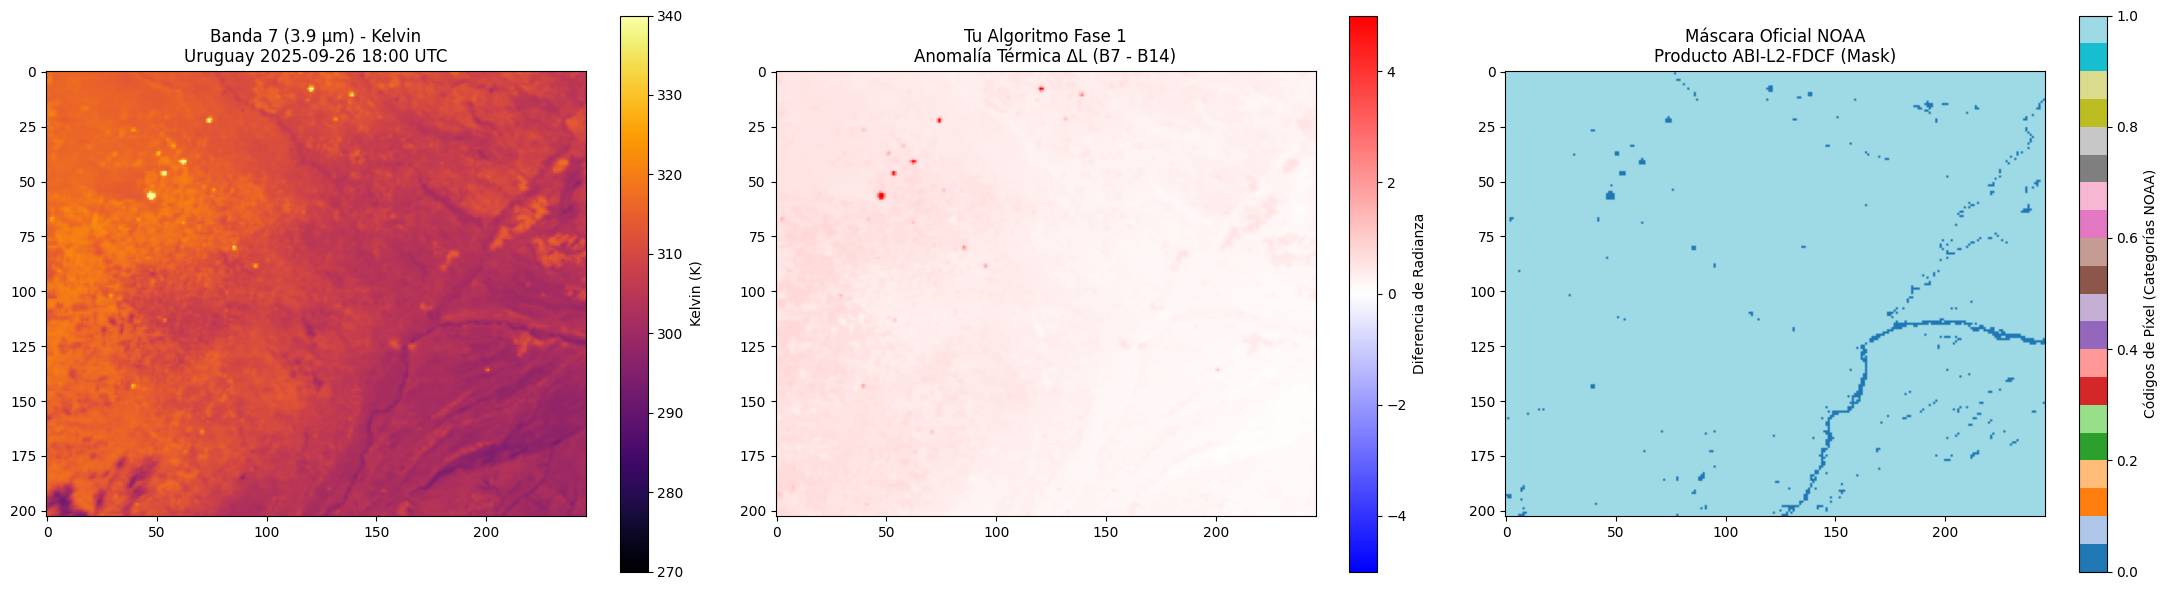

In [15]:
# Definimos el instante de tiempo real de prueba aportado
fecha_test = "2025-09-26 18:00"

# 1. Descarga de bandas L1b para tu algoritmo
bTemp7_uy, rad7_uy   = obtener_datos_banda_colab(fecha_test, 7, REGION_URUGUAY)
bTemp13_uy, rad13_uy = obtener_datos_banda_colab(fecha_test, 13, REGION_URUGUAY)
bTemp14_uy, rad14_uy = obtener_datos_banda_colab(fecha_test, 14, REGION_URUGUAY)
bTemp15_uy, rad15_uy = obtener_datos_banda_colab(fecha_test, 15, REGION_URUGUAY)

# 2. Descarga de la máscara oficial precalculada de la NOAA (L2)
mascara_noaa_uy = obtener_mascara_noaa_colab(fecha_test, REGION_URUGUAY)

# ══════════════════════════════════════════════════════════════════════════════
# Ejecución de las funciones algorítmicas de la Fase 1
# ══════════════════════════════════════════════════════════════════════════════
ang_cenital_sol_uy = np.full_like(bTemp7_uy, 30.0)
ang_resp_sol_uy    = np.full_like(bTemp7_uy, 45.0)

refl_uy, _, _ = preprocesar_imagenes_abi(
    bTemp7=bTemp7_uy, rad7=rad7_uy,
    bTemp13=bTemp13_uy, rad13=rad13_uy,
    bTemp14=bTemp14_uy, rad14=rad14_uy,
    refl2=None,
    ang_cenital_sol=ang_cenital_sol_uy,
    FPT=85.0
)

mascara_fuego_uy = aplicar_filtros_iniciales(
    bTemp7=bTemp7_uy, rad7=rad7_uy,
    bTemp14=bTemp14_uy, rad14=rad14_uy,
    ang_cenital_sol=ang_cenital_sol_uy,
    ang_resp_sol=ang_resp_sol_uy
)

# ══════════════════════════════════════════════════════════════════════════════
# Visualización interactiva en Colab: 3 Paneles alineados
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1: Infrarrojo de Onda Corta
im1 = ax[0].imshow(bTemp7_uy, cmap='inferno', vmin=270, vmax=340)
ax[0].set_title(f"Banda 7 (3.9 µm) - Kelvin\nUruguay {fecha_test} UTC")
fig.colorbar(im1, ax=ax[0], label="Kelvin (K)")

# Panel 2: Tu indicador de anomalía térmica de la Fase 1
im2 = ax[1].imshow(refl_uy, cmap='bwr', vmin=-5, vmax=5)
ax[1].set_title("Tu Algoritmo Fase 1\nAnomalía Térmica ΔL (B7 - B14)")
fig.colorbar(im2, ax=ax[1], label="Diferencia de Radianza")

# Panel 3: Producto Operativo L2 de la NOAA
# Usamos 'tab20' o 'viridis' para mapear los códigos numéricos categóricos
im3 = ax[2].imshow(mascara_noaa_uy==100, cmap='tab20')
ax[2].set_title("Máscara Oficial NOAA\nProducto ABI-L2-FDCF (Mask)")
fig.colorbar(im3, ax=ax[2], label="Códigos de Píxel (Categorías NOAA)")



plt.tight_layout()
plt.show()

Es el resultado de restarle a la radianza de la banda 7 la radianza de la banda 14 (luego de haberla pasado por la función de Planck para simular el espacio de la banda 7). Como usamos el mapa de color bwr (Blue-White-Red) centrado en cero (vmin=-5, vmax=5):

El Fondo Terrestre Estable: La mayor parte del territorio continental de Uruguay debería verse de un color blanco uniforme o un rosado muy pálido. Esto te confirma que la atmósfera y la superficie están estables y que tu función de Planck cruzada está bien calibrada (la diferencia entre bandas en suelo normal es muy cercana a cero).

El Agua y las Nubes: Se pintarán de un color azul nítido (valores negativos). Las nubes y el agua tienden a emitir proporcionalmente más en el infrarrojo térmico limpio (banda 14) que en el canal de 3.9 µm.

Un foco ígneo real va a saltar a la vista inmediatamente como un punto de color rojo intenso y brillante (píxel aislado muy positivo).

In [16]:
def resumen_codigos(mascara):
    valores, conteos = np.unique(mascara, return_counts=True)

    print("\nDistribución de códigos NOAA")
    print("-" * 60)

    for v, c in zip(valores, conteos):
        nombre = CMAP_MASCARA.get(v, ("", f"Código {v}"))[1]
        print(f"{v:>4}: {c:>10,} px  -> {nombre}")

In [17]:
print("=" * 70)
print("FASE 1 — Pipeline NOAA Fire Detection")
print("=" * 70)

fecha_test = "2025-09-26 18:00"

print(f"\n📥 Descargando datos para {fecha_test} UTC...")

bTemp7_uy,  rad7_uy  = obtener_datos_banda_colab(fecha_test, 7, REGION_URUGUAY)
bTemp13_uy, rad13_uy = obtener_datos_banda_colab(fecha_test, 13, REGION_URUGUAY)
bTemp14_uy, rad14_uy = obtener_datos_banda_colab(fecha_test, 14, REGION_URUGUAY)
bTemp15_uy, rad15_uy = obtener_datos_banda_colab(fecha_test, 15, REGION_URUGUAY)
mascara_noaa_uy = obtener_mascara_noaa_colab(fecha_test, REGION_URUGUAY)



ang_cenital_sol_uy = np.full_like(bTemp7_uy, 30.0)
ang_resp_sol_uy = np.full_like(bTemp7_uy, 45.0)
ang_cenital_local_uy = np.full_like(bTemp7_uy, 35.0)

print(
    f"\n✅ Escena cargada: {bTemp7_uy.shape}"
    f"\nTotal píxeles: {bTemp7_uy.size:,}"
)

FASE 1 — Pipeline NOAA Fire Detection

📥 Descargando datos para 2025-09-26 18:00 UTC...
🔍 [GOES-19] Buscando ABI-L1b-B07 para la fecha 2025-09-26 18:00...
 👮🏻‍♂️ File already exists. Do not overwrite: C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF\2025\269\18\OR_ABI-L1b-RadF-M6C07_G19_s20252691800190_e20252691809510_c20252691809557.nc
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B07 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B13 para la fecha 2025-09-26 18:00...
 👮🏻‍♂️ File already exists. Do not overwrite: C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF\2025\269\18\OR_ABI-L1b-RadF-M6C13_G19_s20252691800190_e20252691809511_c20252691809568.nc
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B13 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B14 para la fecha 2025-09-26 18:00...
 👮🏻‍♂️ File already exists. Do not overwrite: C:\Users\pedro\data\noa


📊 Paso 1/6 — Datos crudos ABI


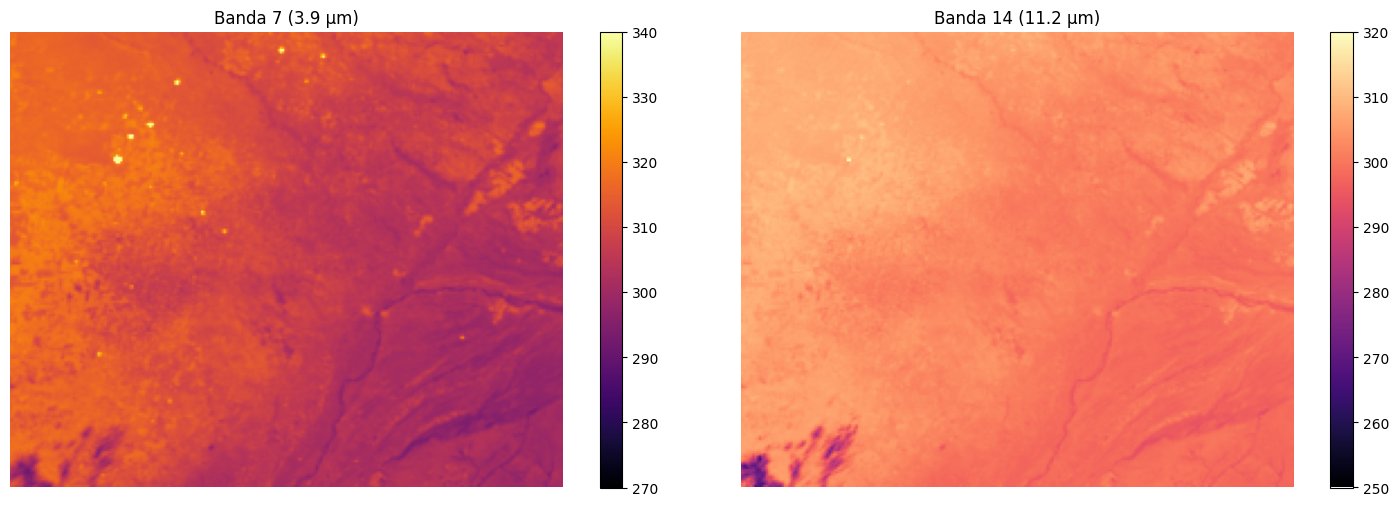

In [18]:
print("\n📊 Paso 1/6 — Datos crudos ABI")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im1 = axes[0].imshow(
    bTemp7_uy,
    cmap="inferno",
    vmin=270,
    vmax=340
)

axes[0].set_title("Banda 7 (3.9 µm)")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(
    bTemp14_uy,
    cmap="magma",
    vmin=250,
    vmax=320
)

axes[1].set_title("Banda 14 (11.2 µm)")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

INFO: Ejecutando §3.4.2.2 — Preprocesamiento de radianzas



📊 Paso 2/6 — Preprocesamiento (§3.4.2.2)
ΔL mínimo : 0.012
ΔL máximo : 21.793
ΔL medio  : 0.345


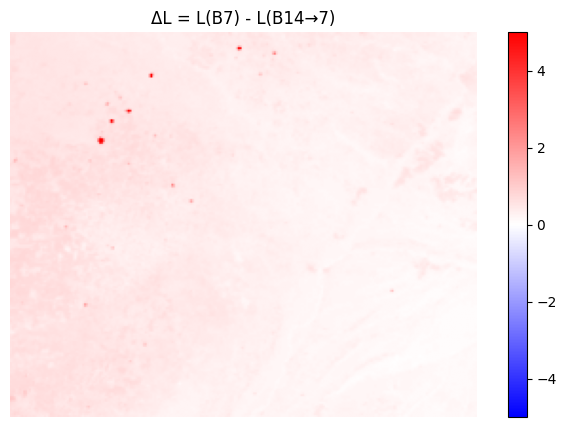

In [19]:
print("\n📊 Paso 2/6 — Preprocesamiento (§3.4.2.2)")

refl_uy, albedo_uy, vis_brightness_uy = (
    preprocesar_imagenes_abi(
        bTemp7=bTemp7_uy,
        rad7=rad7_uy,
        bTemp13=bTemp13_uy,
        rad13=rad13_uy,
        bTemp14=bTemp14_uy,
        rad14=rad14_uy,
        refl2=None,
        ang_cenital_sol=ang_cenital_sol_uy,
        FPT=85.0
    )
)

print(
    f"ΔL mínimo : {np.nanmin(refl_uy):.3f}\n"
    f"ΔL máximo : {np.nanmax(refl_uy):.3f}\n"
    f"ΔL medio  : {np.nanmean(refl_uy):.3f}"
)

plt.figure(figsize=(8,5))

im = plt.imshow(
    refl_uy,
    cmap="bwr",
    vmin=-5,
    vmax=5
)

plt.title("ΔL = L(B7) - L(B14→7)")
plt.colorbar(im)
plt.axis("off")
plt.show()

In [20]:
CMAP_MASCARA = {
    40:  "Espacio exterior",
    50:  "SZA > 80°",
    60:  "Sunglint",
    100: "Candidato válido",
    120: "Missing T7",
    121: "Missing T14",
    123: "Saturación T7",
    124: "Saturación T14",
    125: "Radiancia negativa",
    126: "T7 < 200 K",
    127: "T14 < 200 K",
    200: "Cloud Test 1",
    205: "Cloud Test 2",
    215: "Cloud Test 3",
    220: "Cloud Test 4",
    225: "Cloud Test 5",
    230: "Cloud Test 6",
    201: "Píxel frío"
}

In [21]:
def resumen_codigos(mascara):
    valores, conteos = np.unique(mascara, return_counts=True)

    print("\nDistribución de códigos NOAA")
    print("-" * 60)

    for v, c in zip(valores, conteos):
        nombre = CMAP_MASCARA.get(v, ("", f"Código {v}"))[1]
        print(f"{v:>4}: {c:>10,} px  -> {nombre}")

In [22]:
def render_mascara(
    mascara,
    titulo,
    paso_num=None,
    total_pasos=None
):
    plt.figure(figsize=(8,6))

    plt.imshow(
        mascara,
        cmap="tab20"
    )

    if paso_num is not None:
        plt.title(
            f"Paso {paso_num}/{total_pasos}\n{titulo}"
        )
    else:
        plt.title(titulo)

    plt.colorbar(
        label="Código NOAA"
    )

    plt.axis("off")
    plt.show()


📊 Paso 3/6 — Filtros iniciales (§3.4.2.3)

Distribución de códigos NOAA
------------------------------------------------------------
 100:     49,924 px  -> a
 123:         14 px  -> a


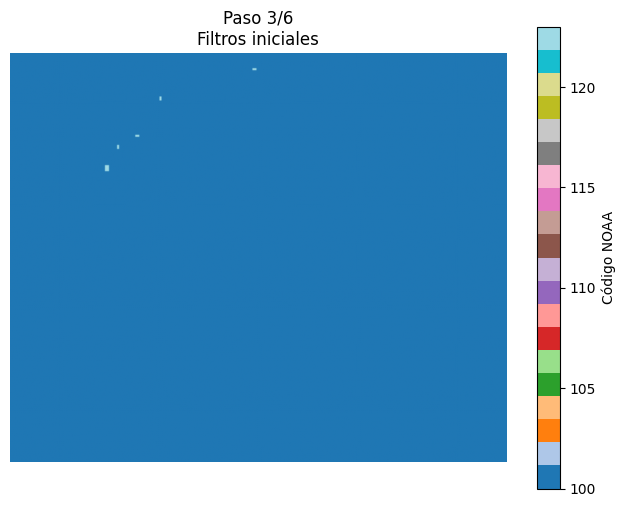

In [23]:
print("\n📊 Paso 3/6 — Filtros iniciales (§3.4.2.3)")

mascara_fuego_uy = aplicar_filtros_iniciales(
    bTemp7=bTemp7_uy,
    rad7=rad7_uy,
    bTemp14=bTemp14_uy,
    rad14=rad14_uy,
    ang_cenital_sol=ang_cenital_sol_uy,
    ang_resp_sol=ang_resp_sol_uy
)

resumen_codigos(mascara_fuego_uy)

render_mascara(
    mascara_fuego_uy,
    "Filtros iniciales",
    paso_num=3,
    total_pasos=6
)


📊 Paso 4/6 — Test de actividad térmica

Distribución de códigos NOAA
------------------------------------------------------------
 100:     49,924 px  -> a
 123:         14 px  -> a


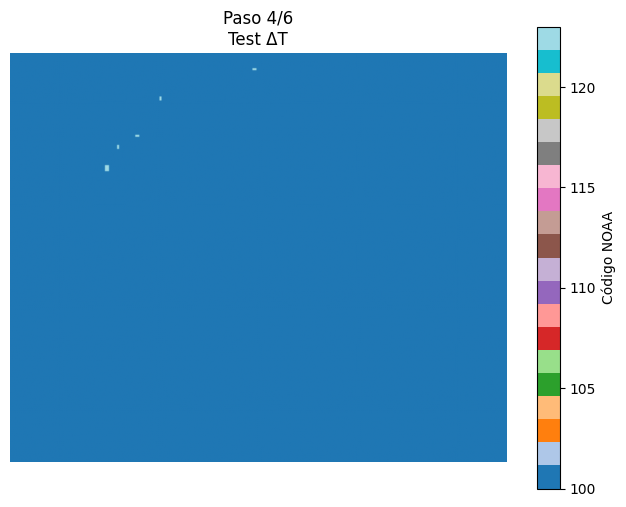

In [24]:
print("\n📊 Paso 4/6 — Test de actividad térmica")

mascara_fuego_uy = aplicar_test_actividad_termica(
    mascara_fuego_uy,
    bTemp7_uy,
    bTemp14_uy
)

resumen_codigos(mascara_fuego_uy)

render_mascara(
    mascara_fuego_uy,
    "Test ΔT",
    paso_num=4,
    total_pasos=6
)


📊 Paso 6/6 — Cloud Tests

Distribución de códigos NOAA
------------------------------------------------------------
 100:     49,908 px  -> a
 123:         14 px  -> a
 200:          9 px  -> l
 220:          7 px  -> l


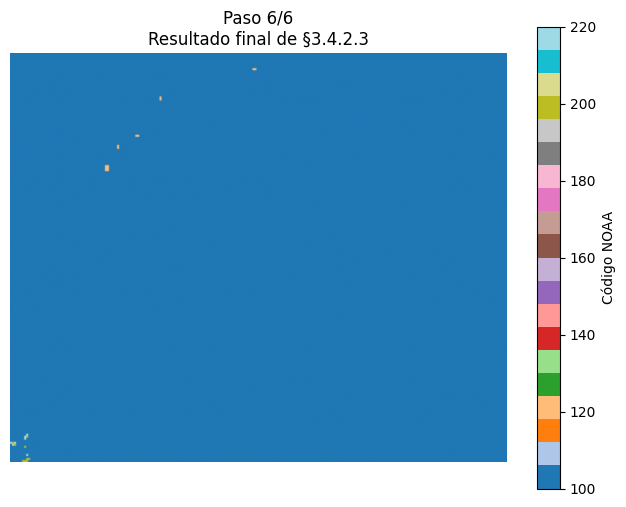

In [25]:
print("\n📊 Paso 6/6 — Cloud Tests")

mascara_fuego_uy, mascara_nubes_uy = (
    aplicar_cloud_tests(
        mascara_fuego=mascara_fuego_uy,
        bTemp7=bTemp7_uy,
        bTemp14=bTemp14_uy,
        bTemp15=bTemp15_uy,
        albedo=albedo_uy,
        ang_cenital_sol=ang_cenital_sol_uy,
        ang_cenital_local=ang_cenital_local_uy
    )
)

resumen_codigos(mascara_fuego_uy)

render_mascara(
    mascara_fuego_uy,
    "Resultado final de §3.4.2.3",
    paso_num=6,
    total_pasos=6
)


Comparación con NOAA.
La máscara NOAA incluye fases posteriores que todavía no fueron ejecutadas en este notebook.


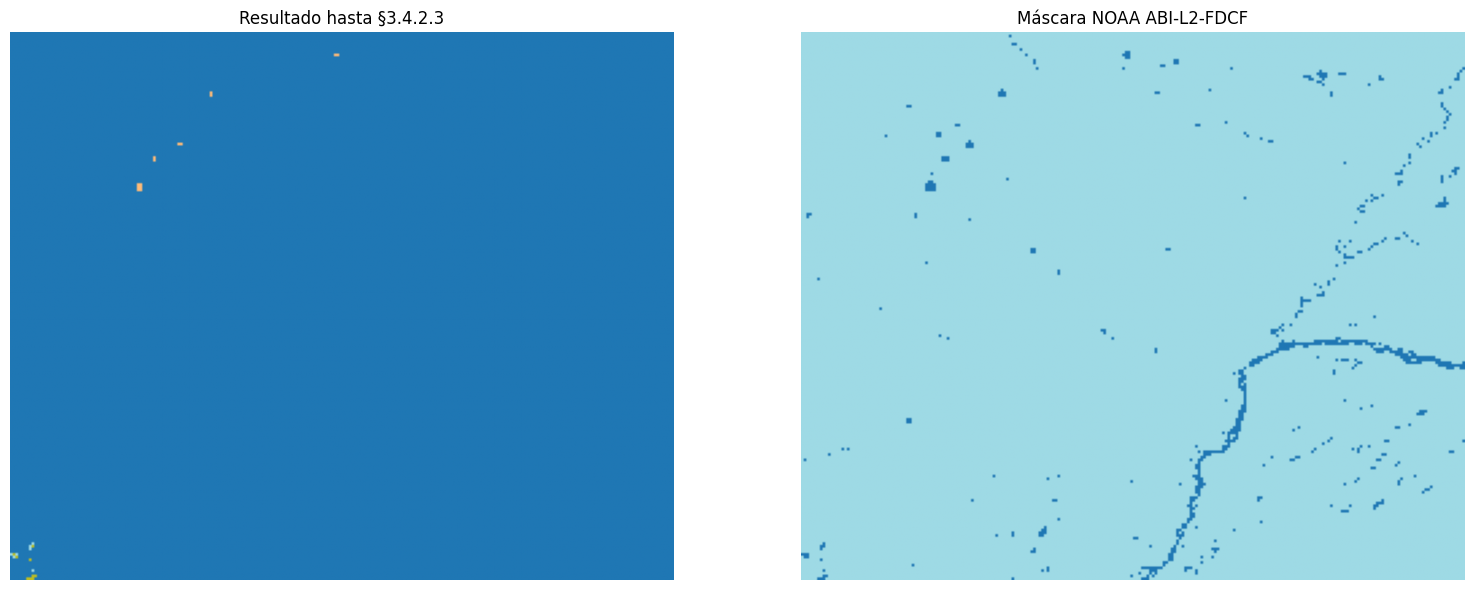

In [26]:
print(
    "\nComparación con NOAA."
    "\nLa máscara NOAA incluye fases posteriores"
    " que todavía no fueron ejecutadas en este notebook."
)

fig, ax = plt.subplots(1, 2, figsize=(16,6))

ax[0].imshow(mascara_fuego_uy, cmap="tab20")
ax[0].set_title("Resultado hasta §3.4.2.3")
ax[0].axis("off")

ax[1].imshow(mascara_noaa_uy==100, cmap="tab20")
ax[1].set_title("Máscara NOAA ABI-L2-FDCF")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [27]:
print("\n📊 Paso 5/6 — Umbrales día/noche")

bTemp7_min_uy, bTemp7_refl_thr_uy = (
    calcular_umbrales_dia_noche(
        ang_cenital_sol_uy
    )
)

print(
    f"T7_min = {bTemp7_min_uy[0,0]:.2f} K\n"
    f"T7_refl_threshold = {bTemp7_refl_thr_uy[0,0]:.2f} K"
)


📊 Paso 5/6 — Umbrales día/noche
T7_min = 297.99 K
T7_refl_threshold = 319.33 K


Clodu test


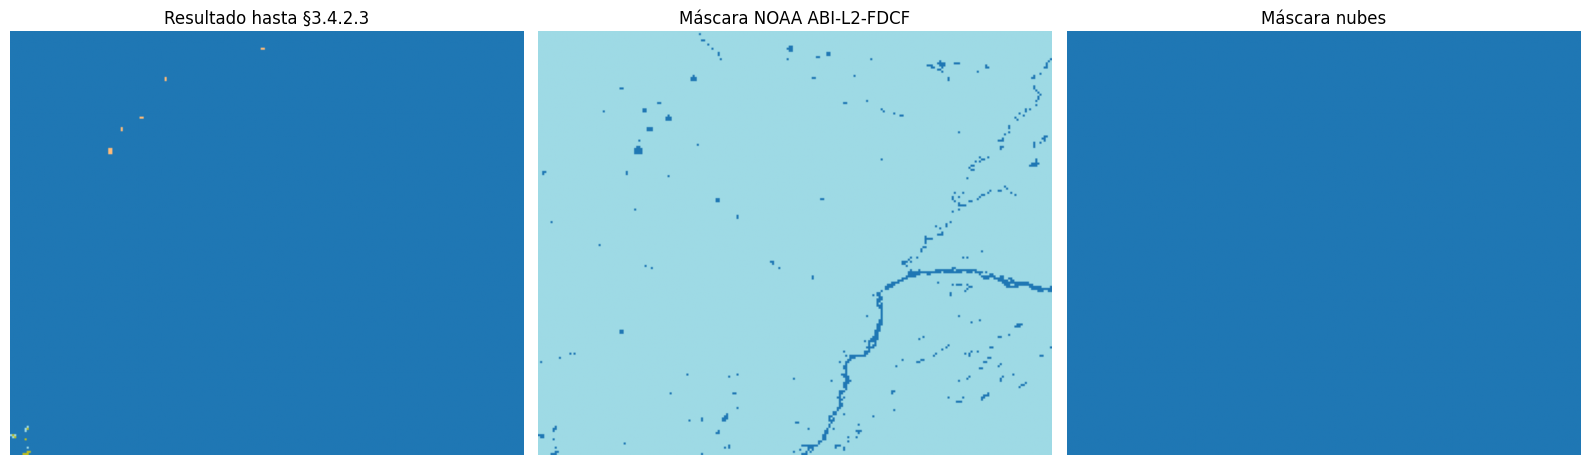

In [ ]:
print("Cloud test")

mascara_fuego_uy, mascara_nubes_uy = aplicar_cloud_tests(mascara_fuego_uy,bTemp7_uy,bTemp14_uy,bTemp15_uy,albedo_uy,ang_cenital_sol_uy,ang_cenital_local_uy)

fig, ax = plt.subplots(1, 3, figsize=(16,6))

ax[0].imshow(mascara_fuego_uy, cmap="tab20")
ax[0].set_title("Resultado hasta §3.4.2.3")
ax[0].axis("off")

ax[1].imshow(mascara_noaa_uy==100, cmap="tab20")
ax[1].set_title("Máscara NOAA ABI-L2-FDCF")
ax[1].axis("off")

ax[2].imshow(mascara_nubes_uy==1, cmap="tab20")
ax[2].set_title("Máscara nubes")
ax[2].axis("off")

plt.tight_layout()
plt.show()